### 不使用额外ancilla的情形

In [1]:
import numpy as np
from TDD.TDD import TDD, Ini_TDD,Clear_TDD,set_index_order,get_unique_table_num,set_root_of_unit,get_count,cont,renormalize,Slicing2,Slicing
from TDD.TDD_Q import cir_2_tn,get_real_qubit_num,add_trace_line,add_inputs,add_outputs,gen_cir
from TDD.TN import Index,Tensor,TensorNetwork
from TDD.Syn import *
import time
import random
from qiskit import QuantumCircuit,qasm2, transpile
import cProfile
from IPython.display import display, HTML,Image
# from PIL import Image
from PIL import Image as PILImage
import networkx as nx
import copy
from qiskit.circuit.library.standard_gates import HGate,U1Gate,U3Gate
from qiskit.quantum_info.operators import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.circuit import CircuitInstruction

import itertools

to_test = False

import warnings

warnings.simplefilter("ignore")

In [2]:
def oracle_syn1(tdd,data_q = -1,n_r=0):

    n = tdd.node.key+1
    cir = Circuit(n+1,[])
    if data_q==-1:
        data_q = n
        
    if tdd.node.key==-1:
        if abs(tdd.weight)<1e-10:
            cir = Circuit(n_r+1,[])
            return cir
        else:
            cir.data.append(Gate('x',{},data_q))
        return cir
        

    the_map=tdd.map
    while the_map.level>-1:
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{},q))
        the_map=the_map.father

    u = tdd.node
    the_map = u.out_maps[1]
    while the_map.level>-1:
            q1 = u.key
            idx = the_map.level
            q = int(tdd.key_2_index[idx][1:])
            if the_map.x==1:
                cir.data.append(Gate('x',{q1:1},q))
            the_map=the_map.father
            
    bran_tdd = get_branch_dd(u,0)
    cir_end_t0 = oracle_syn1(bran_tdd,data_q)
    
    if tdd.node.successor[0]!=tdd.node.successor[1]:
        bran_tdd = get_branch_dd(u,1)
        cir_end_t1 = oracle_syn1(bran_tdd,data_q)
        cir_end_t0 = get_controlled_circuit2(cir_end_t0,{u.key:0},1)
        cir.data+=cir_end_t0.data
        cir_end_t1 = get_controlled_circuit2(cir_end_t1,{u.key:1},1)
        cir.data+=cir_end_t1.data
    else:
        if abs(u.out_weight[1])<1e-10:
            cir_end_t0 = get_controlled_circuit2(cir_end_t0,{u.key:0},1)
        cir.data+=cir_end_t0.data

    the_map = u.out_maps[1]
    while the_map.level>-1:
            q1 = u.key
            idx = the_map.level
            q = int(tdd.key_2_index[idx][1:])
            if the_map.x==1:
                cir.data.append(Gate('x',{q1:1},q))
            the_map=the_map.father

    the_map=tdd.map
    while the_map.level>-1:
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{},q))
        the_map=the_map.father    
    return cir

def verify_success(cir,data,n):
    # print(data)
    for k in range(2**n):
        input = format(k & ((1 << n) - 1), f'0{n}b')
        current_state = {n-1-q : int(input[q]) for q in range(n)}
        current_state[n]=0
        current_state_s = copy.copy(current_state)
        for g in cir.data:
            flag = True
            for q in g.q_c:
                if g.q_c[q]!=current_state[q]:
                    flag = False
                    break
            if flag:
                current_state[g.q_t]=1-current_state[g.q_t]
        for q in range(len(current_state)-1):
            if current_state[q]!=current_state_s[q]:
                print('Not Successful, see input:',input)
                break
        if current_state[n]!=data[k]:
            print('Not Successful, see input:',input)
    print('Successful')

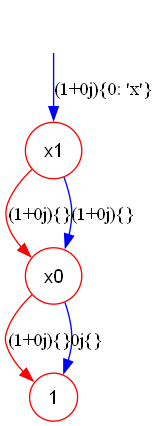

In [3]:
n = 2
tdd,data = get_ramdom_TDD(n)
tdd.show()

In [4]:
t_start = time.time()
cir = oracle_syn1(tdd,n_r=n)
print(time.time()-t_start)
verify_success(cir,data,n)
print(cir)

0.0
Successful
[('x', '()', 0, array([[0, 1],
       [1, 0]])),('x', '(0: 0)', 2, array([[0, 1],
       [1, 0]])),('x', '()', 0, array([[0, 1],
       [1, 0]])),]


0.0


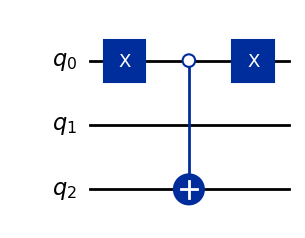

In [5]:
t_start = time.time()
cir_qis = cir.to_qis_cir()
print(time.time()-t_start)
cir_qis.draw('mpl')

In [6]:
t_start = time.time()
qc_t = transpile(cir_qis,optimization_level=3)
print(time.time()-t_start)
print("\n转译后:")
print(qc_t.draw())

0.30040454864501953

转译后:
     ┌───┐     ┌───┐
q_0: ┤ X ├──o──┤ X ├
     └───┘  │  └───┘
q_1: ───────┼───────
          ┌─┴─┐     
q_2: ─────┤ X ├─────
          └───┘     
